In [1]:
pip install transformers>=4.41.2 accelerate>=0.31.0

Note: you may need to restart the kernel to use updated packages.


In [ ]:
from transformers import AutoModelForCausalLM, AutoTokenizer, pipeline

# Load model and tokenizer
tokenizer = AutoTokenizer.from_pretrained("microsoft/Phi-3-mini-4k-instruct")

model = AutoModelForCausalLM.from_pretrained(
    "microsoft/Phi-3-mini-4k-instruct",
    device_map="cuda",
    torch_dtype="auto",
    trust_remote_code=False,
)



d:\2026-courses\LLMs-Handson\venv\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Loading weights: 100%|██████████| 195/195 [00:27<00:00,  7.15it/s]
The following generation flags are not valid and may be ignored: ['temperature']. Set `TRANSFORMERS_VERBOSITY=info` for more details.
Passing `generation_config` together with generation-related arguments=({'max_new_tokens', 'do_sample'}) is deprecated and will be removed in future versions. Please pass either a `generation_config` object OR all generation parameters explicitly, but not both.


In [6]:
# Create a pipeline
generator = pipeline(
    "text-generation",
    model=model,
    tokenizer=tokenizer,
    return_full_text=False,
    max_new_tokens=500,
    do_sample=False,
)

In [9]:
prompt = "Write an email apologizing to Sarah for the tragic gardening mishap. Explain how it happened."

output = generator(prompt)

output

Both `max_new_tokens` (=500) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


[{'generated_text': " Mention the steps you're taking to prevent it in the future.\n\nDear Sarah,\n\nI hope this message finds you well. I am writing to express my sincerest apologies for the unfortunate incident that occurred in your garden. It was a tragic mishap that I deeply regret.\n\nThe incident happened when I was attempting to help you with your gardening project. Unfortunately, in my eagerness to assist, I accidentally knocked over a large pot of soil, causing it to spill all over your beautiful flowerbed. I understand how much time and effort you put into maintaining your garden, and I am truly sorry for the damage caused.\n\nPlease know that I take full responsibility for my actions and the consequences that followed. I realize now that my enthusiasm may have led to carelessness, and I assure you that I will be more cautious in the future.\n\nTo prevent such incidents from happening again, I have taken several steps:\n\n1. I have enrolled in a gardening course to learn prop

In [8]:
output[0]['generated_text']

', express your sincere regret, and offer to replace the damaged plants.\n\n\nEmail to Sarah:\n\nSubject: Sincere Apologies for the Gardening Mishap\n\n\nDear Sarah,\n\n\nI hope this message finds you well. I am writing to express my deepest apologies for the unfortunate incident that occurred in your garden yesterday.\n\n\nAs you know, I have always admired the beauty and tranquility of your garden. It was with great regret that I accidentally damaged some of your beloved plants while attempting to install a new irrigation system. I understand that this was not only a waste of your time and effort but also a source of distress.\n\n\nPlease know that I take full responsibility for my actions and the consequences that followed. I am truly sorry for any inconvenience and disappointment this may have caused you.\n\n\nTo make amends, I would like to offer to replace the damaged plants with new ones of the same species and quality. I am also willing to cover any additional costs associated 

In [10]:
model

Phi3ForCausalLM(
  (model): Phi3Model(
    (embed_tokens): Embedding(32064, 3072, padding_idx=32000)
    (layers): ModuleList(
      (0-31): 32 x Phi3DecoderLayer(
        (self_attn): Phi3Attention(
          (o_proj): Linear(in_features=3072, out_features=3072, bias=False)
          (qkv_proj): Linear(in_features=3072, out_features=9216, bias=False)
        )
        (mlp): Phi3MLP(
          (gate_up_proj): Linear(in_features=3072, out_features=16384, bias=False)
          (down_proj): Linear(in_features=8192, out_features=3072, bias=False)
          (activation_fn): SiLUActivation()
        )
        (input_layernorm): Phi3RMSNorm((3072,), eps=1e-05)
        (post_attention_layernorm): Phi3RMSNorm((3072,), eps=1e-05)
        (resid_attn_dropout): Dropout(p=0.0, inplace=False)
        (resid_mlp_dropout): Dropout(p=0.0, inplace=False)
      )
    )
    (norm): Phi3RMSNorm((3072,), eps=1e-05)
    (rotary_emb): Phi3RotaryEmbedding()
  )
  (lm_head): Linear(in_features=3072, out_featur

## Choosing a signle token from the probability distribution (Sampling/decoding)


In [ ]:
prompt = "The capital of France is"

# Tokenize the input prompt
input_ids = tokenizer(prompt, return_tensors="pt").input_ids

# Tokenize the input prompt
input_ids = input_ids.to("cuda")

# Get the output of the model before the lm_head
model_output = model.model(input_ids)

# Get the output of the lm_head
lm_head_output = model.lm_head(model_output[0])


BaseModelOutputWithPast(last_hidden_state=tensor([[[-0.3223,  1.1719,  0.2754,  ..., -0.2715,  0.7227,  0.1270],
         [-0.1318,  0.3105,  0.3848,  ...,  0.5391, -0.1357, -0.6211],
         [-0.5781,  1.0781,  1.5625,  ..., -0.4219,  0.2754,  0.4062],
         [-0.4082,  0.6523,  0.2422,  ..., -0.0732,  0.8047, -0.6562],
         [-0.6719,  0.6875,  0.5547,  ...,  0.2480,  0.1943, -0.2793]]],
       device='cuda:0', dtype=torch.bfloat16, grad_fn=<MulBackward0>), past_key_values=DynamicCache(layers=[DynamicSlidingWindowLayer, DynamicSlidingWindowLayer, DynamicSlidingWindowLayer, DynamicSlidingWindowLayer, DynamicSlidingWindowLayer, DynamicSlidingWindowLayer, DynamicSlidingWindowLayer, DynamicSlidingWindowLayer, DynamicSlidingWindowLayer, DynamicSlidingWindowLayer, DynamicSlidingWindowLayer, DynamicSlidingWindowLayer, DynamicSlidingWindowLayer, DynamicSlidingWindowLayer, DynamicSlidingWindowLayer, DynamicSlidingWindowLayer, DynamicSlidingWindowLayer, DynamicSlidingWindowLayer, Dynamic

In [ ]:
token_id = lm_head_output[0,-1].argmax(-1)
tokenizer.decode(token_id)



'Paris'

: 

In [16]:
lm_head_output.shape

torch.Size([1, 5, 32064])

In [39]:
import torch
import torch.nn.functional as F

# Get the logits for the last token position (the next token to generate)
last_token_logits = lm_head_output[0, -1]

# Convert logits to probabilities using softmax
probabilities = F.softmax(last_token_logits, dim=-1)

# Get the top 10 most probable tokens
top_k = 10
top_probs, top_indices = torch.topk(probabilities, top_k)

print("Top 10 most probable next tokens:\n")
print(f"{'Rank':<6} {'Token':<20} {'Token ID':<10} {'Probability':<12} {'Logit':<10}")
print("-" * 70)

for i, (prob, idx) in enumerate(zip(top_probs, top_indices)):
    token = tokenizer.decode(idx)
    logit = last_token_logits[idx].item()
    print(f"{i+1:<6} {token:<20} {idx.item():<10} {prob.item():<12.6f} {logit:<10.2f}")

# Show the selected token
print(f"\n{'='*70}")
print(f"Selected token (argmax): '{tokenizer.decode(top_indices[0])}' with probability {top_probs[0].item():.6f}")
print(f"{'='*70}")

Top 10 most probable next tokens:

Rank   Token                Token ID   Probability  Logit     
----------------------------------------------------------------------
1      Paris                3681       0.878906     44.50     
2      _                    903        0.026489     41.00     
3      not                  451        0.012512     40.25     
4      ...                  856        0.007599     39.75     
5      __                   4770       0.005920     39.50     
6      known                2998       0.005920     39.50     
7      
                    13         0.005920     39.50     
8      a                    263        0.003586     39.00     
9      [                    518        0.002182     38.50     
10     :                    29901      0.002182     38.50     

Selected token (argmax): 'Paris' with probability 0.878906


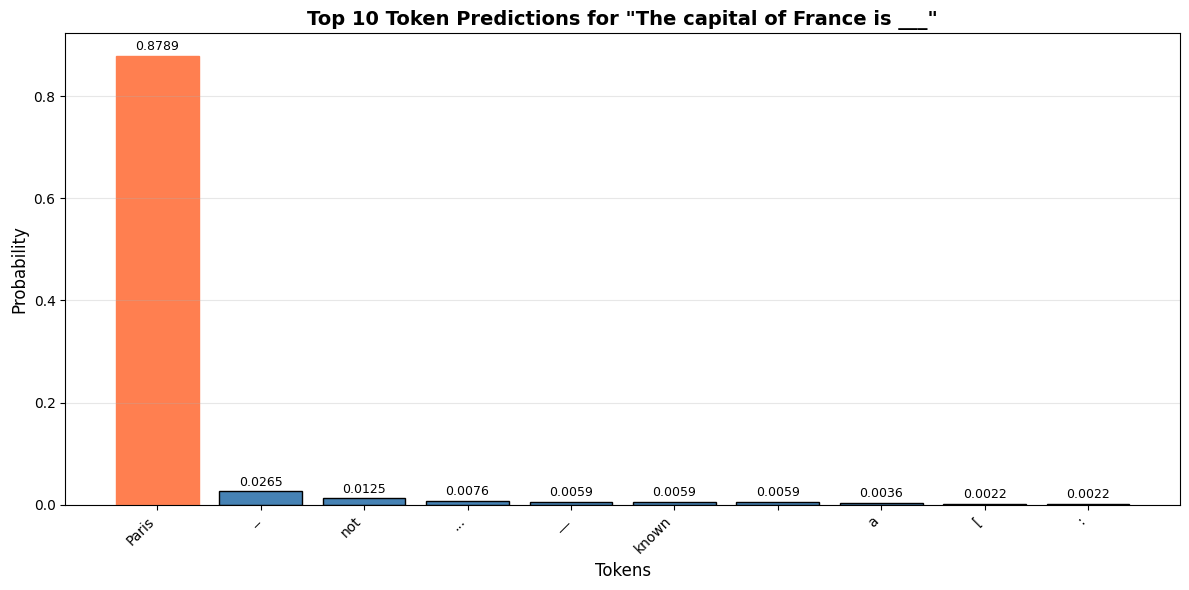


The model selected 'Paris' because it has the highest probability: 0.878906


In [43]:
import matplotlib.pyplot as plt
import numpy as np

# Visualize the top 10 tokens with a bar chart
tokens_list = [tokenizer.decode(idx) for idx in top_indices]
probs_list = [prob.item() for prob in top_probs]

plt.figure(figsize=(12, 6))
bars = plt.bar(range(len(tokens_list)), probs_list, color='steelblue', edgecolor='black')

# Highlight the selected token (Paris) in a different color
bars[0].set_color('coral')

plt.xlabel('Tokens', fontsize=12)
plt.ylabel('Probability', fontsize=12)
plt.title('Top 10 Token Predictions for "The capital of France is ___"', fontsize=14, fontweight='bold')
plt.xticks(range(len(tokens_list)), tokens_list, rotation=45, ha='right')
plt.grid(axis='y', alpha=0.3)

# Add probability values on top of bars
for i, (bar, prob) in enumerate(zip(bars, probs_list)):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005, 
             f'{prob:.4f}', ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.show()

print(f"\nThe model selected 'Paris' because it has the highest probability: {probs_list[0]:.6f}")

In [44]:
# Show how confident the model is
paris_prob = top_probs[0].item()
top_10_total_prob = top_probs.sum().item()
remaining_prob = 1.0 - top_10_total_prob

print(f"Probability Analysis:")
print(f"-" * 50)
print(f"Paris:                     {paris_prob:.6f} ({paris_prob*100:.2f}%)")
print(f"Other top 9 tokens:        {top_10_total_prob - paris_prob:.6f} ({(top_10_total_prob - paris_prob)*100:.2f}%)")
print(f"All remaining 32,054 tokens: {remaining_prob:.6f} ({remaining_prob*100:.2f}%)")
print(f"-" * 50)
print(f"\nThe model is {paris_prob*100:.2f}% confident that 'Paris' is the correct next token!")

Probability Analysis:
--------------------------------------------------
Paris:                     0.878906 (87.89%)
Other top 9 tokens:        0.074219 (7.42%)
All remaining 32,054 tokens: 0.046875 (4.69%)
--------------------------------------------------

The model is 87.89% confident that 'Paris' is the correct next token!


In [45]:
## Understanding the complete token selection process

print("=" * 70)
print("TOKEN SELECTION PROCESS - Step by Step")
print("=" * 70)

print("\n1️⃣ INPUT:")
print(f"   Prompt: '{prompt}'")
print(f"   Tokenized IDs: {input_ids[0].tolist()}")
print(f"   Tokens: {[tokenizer.decode(tid) for tid in input_ids[0]]}")

print("\n2️⃣ MODEL FORWARD PASS:")
print(f"   Model processes {len(input_ids[0])} input tokens")
print(f"   Output shape: {lm_head_output.shape}")
print(f"   - Batch size: 1")
print(f"   - Sequence length: {lm_head_output.shape[1]}")
print(f"   - Vocabulary size: {lm_head_output.shape[2]}")

print("\n3️⃣ LOGITS (Last Position):")
print(f"   Raw logits shape: {last_token_logits.shape}")
print(f"   Max logit value: {last_token_logits.max().item():.2f}")
print(f"   Min logit value: {last_token_logits.min().item():.2f}")

print("\n4️⃣ SOFTMAX (Convert to Probabilities):")
print(f"   Probabilities sum: {probabilities.sum().item():.6f} (should be ~1.0)")
print(f"   Max probability: {probabilities.max().item():.6f}")

print("\n5️⃣ GREEDY DECODING (Argmax):")
print(f"   Selected token ID: {top_indices[0].item()}")
print(f"   Selected token: '{tokenizer.decode(top_indices[0])}'")
print(f"   Confidence: {top_probs[0].item()*100:.2f}%")

print("\n" + "=" * 70)

TOKEN SELECTION PROCESS - Step by Step

1️⃣ INPUT:
   Prompt: 'The capital of France is'
   Tokenized IDs: [450, 7483, 310, 3444, 338]
   Tokens: ['The', 'capital', 'of', 'France', 'is']

2️⃣ MODEL FORWARD PASS:
   Model processes 5 input tokens
   Output shape: torch.Size([1, 5, 32064])
   - Batch size: 1
   - Sequence length: 5
   - Vocabulary size: 32064

3️⃣ LOGITS (Last Position):
   Raw logits shape: torch.Size([32064])
   Max logit value: 44.50
   Min logit value: 12.56

4️⃣ SOFTMAX (Convert to Probabilities):
   Probabilities sum: 1.000000 (should be ~1.0)
   Max probability: 0.878906

5️⃣ GREEDY DECODING (Argmax):
   Selected token ID: 3681
   Selected token: 'Paris'
   Confidence: 87.89%



In [40]:
last_token_logits = lm_head_output[0, -1]

In [41]:
last_token_logits

tensor([27.8750, 29.3750, 28.0000,  ..., 20.3750, 20.3750, 20.3750],
       device='cuda:0', dtype=torch.bfloat16, grad_fn=<SelectBackward0>)